In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prajwal624girase/food-delivary-dataset/Food_Delivery_Route_Efficiency_Dataset.csv


In [2]:
#================================================= Import Modules =================================================#
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
#================================================= Ignore All Warnings =================================================#
warnings.filterwarnings('ignore')

In [4]:
#================================================= Load Dataset =================================================#
df = pd.read_csv("/kaggle/input/datasets/prajwal624girase/food-delivary-dataset/Food_Delivery_Route_Efficiency_Dataset.csv")

In [5]:
#================================================= Dataset Overview =================================================#
print("#" + "=" * 140 + "#")
display(df.head()) # Preview The Dataset First 5 Rows
print("#" + "=" * 140 + "#")
print("Shape: ",df.shape) # Dataset Shape
print("#" + "=" * 140 + "#")
display(df.info()) # About Dataset
print("#" + "=" * 140 + "#")
display(df.describe()) # Dataset Condition
print("#" + "=" * 140 + "#")
display(df.select_dtypes(include = ['number']).skew()) # Check Numeric Columns Spread
print("#" + "=" * 140 + "#")
display(df.select_dtypes(include = ['number']).cov()) # Check Numeric Columns Relation
print("#" + "=" * 140 + "#")
display(df.select_dtypes(include = ['number']).corr()) # Check The Correlation of Numeric Columns
print("#" + "=" * 140 + "#")

#============================================================================================================================================#


,order_id,distance_km,delivery_time_min,traffic_level,route_length_km,delivery_mode,weather,order_time,restaurant_zone,customer_zone
0,1,7.97,63.8,High,9.75,Bicycle,Clear,2025-01-01 15:29,South,North
1,2,0.90,7.6,High,1.28,Car,Cloudy,2025-01-03 00:47,West,North
2,3,11.12,78.0,Medium,16.65,Bike,Rainy,2025-01-04 17:32,South,Central
3,4,4.90,24.8,Low,5.25,Scooter,Rainy,2025-01-01 14:12,Central,Central
4,5,10.04,56.0,High,11.34,Car,Rainy,2025-01-02 16:50,West,North


#============================================================================================================================================#
Shape:  (200, 10)
#============================================================================================================================================#
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           200 non-null    int64  
 1   distance_km        200 non-null    float64
 2   delivery_time_min  200 non-null    float64
 3   traffic_level      200 non-null    object 
 4   route_length_km    200 non-null    float64
 5   delivery_mode      200 non-null    object 
 6   weather            200 non-null    object 
 7   order_time         200 non-null    object 
 8   restaurant_zone    200 non-null    object 
 9   customer_zone      200 non-null    object 
dtypes: float64

None

#============================================================================================================================================#


...

#============================================================================================================================================#


,order_id,distance_km,delivery_time_min,route_length_km
order_id,3350.000000,23.695101,255.742462,32.729372
distance_km,23.695101,11.369834,78.698139,14.037136
delivery_time_min,255.742462,78.698139,629.203286,102.189944
route_length_km,32.729372,14.037136,102.189944,18.517589


#============================================================================================================================================#


,order_id,distance_km,delivery_time_min,route_length_km
order_id,1.000000,0.121411,0.176151,0.131408
distance_km,0.121411,1.000000,0.930448,0.967407
delivery_time_min,0.176151,0.930448,1.000000,0.946718
route_length_km,0.131408,0.967407,0.946718,1.000000


#============================================================================================================================================#


In [6]:
#================================================= Dataset Cleaning =================================================#
print("#" + "=" * 140 + "#")
print("Total Null Values Present In Dataset: ",df.isnull().sum()) # Check Null Values
print("#" + "=" * 140 + "#")
print("Total Duplicates Values Present In Dataset: ",df.duplicated().sum()) # Check Duplicates Values
print("#" + "=" * 140 + "#")
# Change The DataType order_time Column
df['order_time'] = pd.to_datetime(df['order_time'])
# Extract The Year,Day,Month Columns from order_time Column
df['order_year'] = df['order_time'].dt.year
df['order_month'] = df['order_time'].dt.month
df['order_day'] = df['order_time'].dt.day
# Drop the order_time  and order_id column
df.drop(columns = ['order_id','order_time'],errors = 'ignore',inplace = True)
# Convert All Object Columns In Lower-case
object_columns = df.select_dtypes(include = ['object']).columns
df[object_columns] = df[object_columns].apply(lambda x:x.str.lower())
# Change The DataType of All Object Columns to Category Columns
object_columns = df.select_dtypes(include = ['object']).columns
df[object_columns] = df[object_columns].apply(lambda x:x.astype('category'))

#============================================================================================================================================#
Total Null Values Present In Dataset:  order_id             0
distance_km          0
delivery_time_min    0
traffic_level        0
route_length_km      0
delivery_mode        0
weather              0
order_time           0
restaurant_zone      0
customer_zone        0
dtype: int64
#============================================================================================================================================#
Total Duplicates Values Present In Dataset:  0
#============================================================================================================================================#


#==================================================#
distance_km Has 0 Outliers
#==================================================#


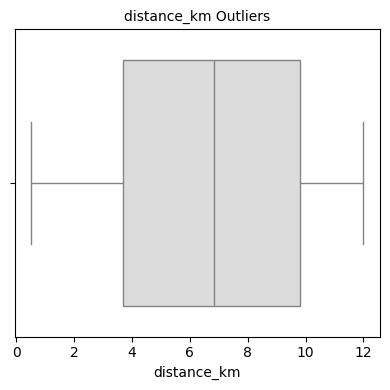

#==================================================#
delivery_time_min Has 1 Outliers
#==================================================#


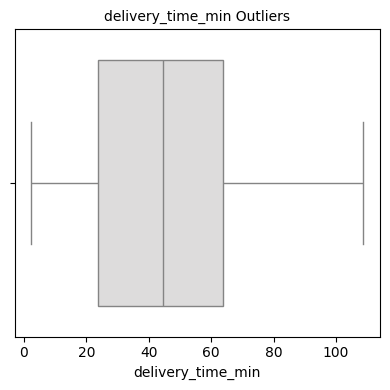

#==================================================#
route_length_km Has 0 Outliers
#==================================================#


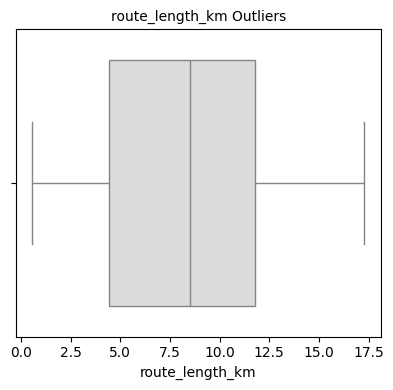

#==================================================#
order_year Has 0 Outliers
#==================================================#


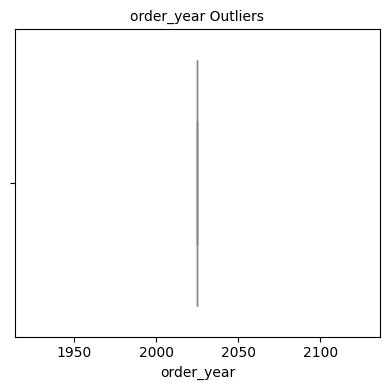

#==================================================#
order_month Has 0 Outliers
#==================================================#


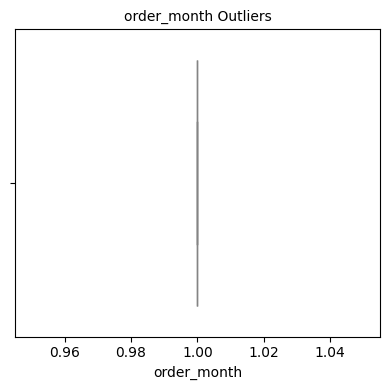

#==================================================#
order_day Has 0 Outliers
#==================================================#


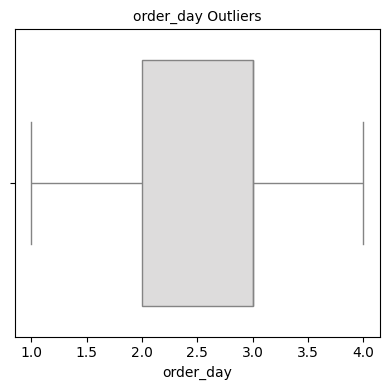

Total Unique Outlier Rows: 1
Percentage of Dataset:    0.5%


In [7]:
#================================================= Outlier's Detection =================================================#
# Using IQR Method:

outlier_data = df.copy()
outlier_box = set()
numeric_columns = df.select_dtypes(include = ['number']).columns
for num_cols in numeric_columns:
    Q1 = outlier_data[num_cols].quantile(0.25)
    Q3 = outlier_data[num_cols].quantile(0.75)
    IQR = Q3 - Q1
    Lower_round = Q1 - 1.0 * IQR
    Upper_round = Q3 + 1.0 * IQR
    outliers = outlier_data[(outlier_data[num_cols] < Lower_round) | (outlier_data[num_cols] > Upper_round)]
    outlier_box.update(outliers.index)
    print("#" + "=" * 50 + "#")
    print(f'{num_cols} Has {len(outliers)} Outliers')
    print("#" + "=" * 50 + "#")
    plt.figure(figsize = (4,4))
    plt.title(f'{num_cols} Outliers',fontsize = 10)
    sns.boxplot(x = outlier_data[num_cols],palette = 'coolwarm')
    plt.tight_layout()
    plt.show()

total_per = (len(outlier_box) / len(outlier_data)) * 100
print("="*30)
print(f"Total Unique Outlier Rows: {len(outlier_box)}")
print(f"Percentage of Dataset:    {total_per:.2}%")
print("="*30)


In [8]:
# #================================================= Outlier's Detection =================================================#
# # Using Z-score Method:
# from scipy import stats
# outlier_data = df.copy()
# outlier_box = set()
# numeric_columns = df.select_dtypes(include = ['number']).columns
# for num_cols in numeric_columns:
#     z = np.abs(stats.zscore(outlier_data[num_cols]))
#     outliers = outlier_data[z > 3]
#     outlier_box.update(outliers.index)
#     print("#" + "=" * 50 + "#")
#     print(f'{num_cols} Has {len(outliers)} Outliers')
#     print("#" + "=" * 50 + "#")
#     plt.figure(figsize = (4,4))
#     plt.title(f'{num_cols} Outliers',fontsize = 10)
#     sns.boxplot(x = outlier_data[num_cols],palette = 'coolwarm')
#     plt.tight_layout()
#     plt.show()

# total_per = (len(outlier_box) / len(outlier_data)) * 100
# print("="*30)
# print(f"Total Unique Outlier Rows: {len(outlier_box)}")
# print(f"Percentage of Dataset:    {total_per:.2}%")
# print("="*30)


In [9]:
#================================================= Remove Outlier's =================================================#
df = df.drop(index = list(outlier_box),errors = 'ignore')

In [10]:
#================================================= Filtering Dataset =================================================#
# Check All Category Columns Type's
categorical_columns = df.select_dtypes(include = ['category'])
for cat_cols in categorical_columns:
    print("#" + "=" * 50 + "#")
    print(df[cat_cols].value_counts())

#==================================================#
traffic_level
high      68
medium    66
low       65
Name: count, dtype: int64
#==================================================#
delivery_mode
scooter    52
bicycle    51
bike       49
car        47
Name: count, dtype: int64
#==================================================#
weather
cloudy    55
rainy     54
windy     50
clear     40
Name: count, dtype: int64
#==================================================#
restaurant_zone
south      53
central    47
west       41
north      30
east       28
Name: count, dtype: int64
#==================================================#
customer_zone
north      46
east       45
central    38
south      36
west       34
Name: count, dtype: int64


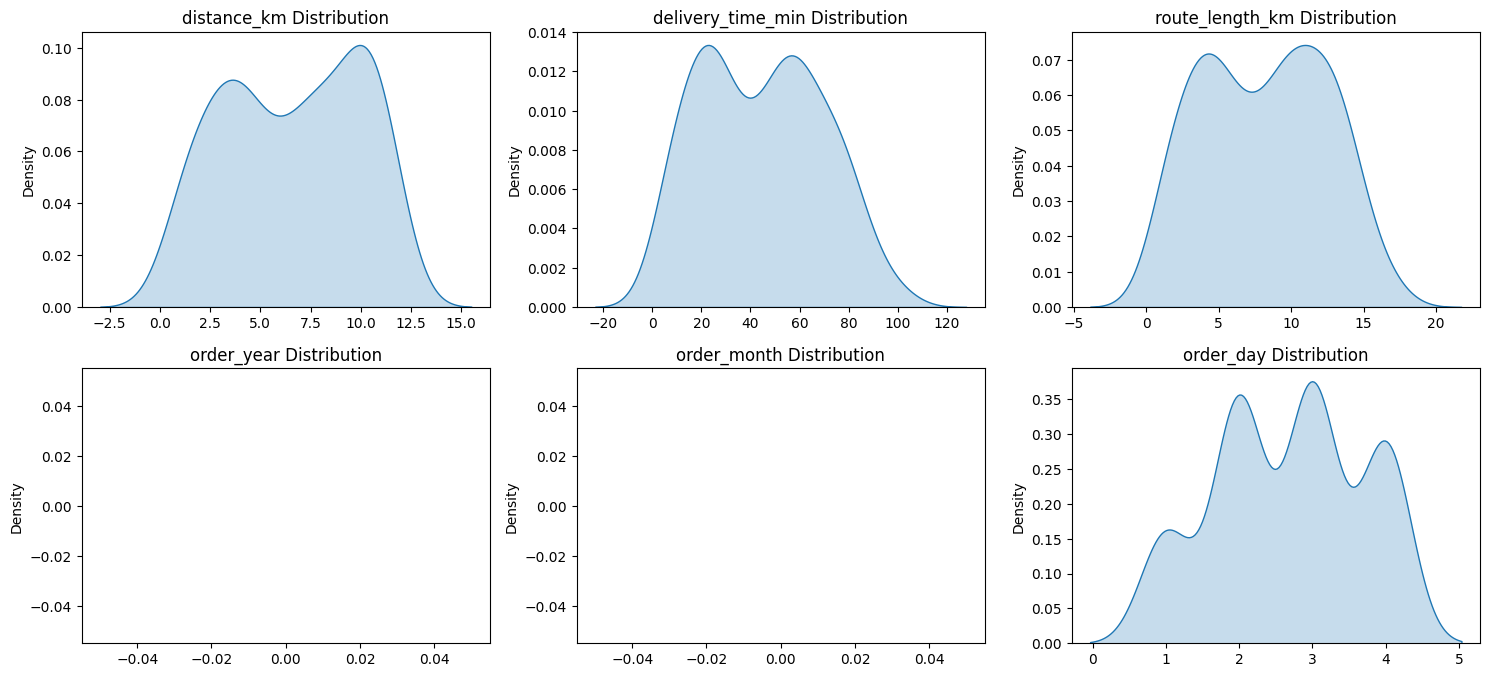

In [11]:
#================================================= Filtering Dataset =================================================#
# Distribution of All Numeric Columns
numeric_cols = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(15, 10)) 
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i) 
    sns.kdeplot(df[col], fill=True)
    plt.title(f'{col} Distribution')
    plt.xlabel('')
plt.tight_layout()
plt.show()


In [12]:
#================================================= Filtering Dataset =================================================#
# Check How Many Customer Has alive In North and distance km is more than 10 and root length is more than 14
df[(df['distance_km'] > 10) & (df['customer_zone'] == 'north') & (df['route_length_km'] > 14)].shape[0]
print("Only 3 Customer Has Alive In North and distance km is more than 10 and root length is more than 14")
# Check How Many Customer Has alive In South and distance km is more than 10 and root length is more than 14
df[(df['distance_km'] > 10) & (df['customer_zone'] == 'south') & (df['route_length_km'] > 14)].shape[0]
print("Only 3 Customer Has Alive In South and distance km is more than 10 and root length is more than 14")
# Check How Many Customer Has alive In east and distance km is more than 10 and root length is more than 14
df[(df['distance_km'] > 10) & (df['customer_zone'] == 'south') & (df['route_length_km'] > 14)].shape[0]
print("Only 3 Customer Has Alive In East and distance km is more than 10 and root length is more than 14")

Only 3 Customer Has Alive In North and distance km is more than 10 and root length is more than 14
Only 3 Customer Has Alive In South and distance km is more than 10 and root length is more than 14
Only 3 Customer Has Alive In East and distance km is more than 10 and root length is more than 14


In [13]:
#================================================= Filtering Dataset =================================================#
df.groupby(['weather','traffic_level'])['delivery_time_min'].agg(
    Maximum_min = 'max',
    Minmum_min = 'min',
    Average_min = 'mean'
).unstack()

Maximum_min               Minmum_min             Average_min  \
traffic_level        high    low medium       high  low medium        high   
weather                                                                      
clear                81.1  102.3   83.6       18.8  9.5    3.0   50.125000   
cloudy               82.4   89.0   99.0        7.1  2.9    7.9   43.429412   
rainy                85.7   78.1   83.4        5.2  7.3    2.4   45.363158   
windy                87.3   97.1   62.2        6.0  9.9    8.3   45.020000   

                                     
traffic_level        low     medium  
weather                              
clear          44.231250  31.791667  
cloudy         56.180000  49.166667  
rainy          37.456250  41.194737  
windy          48.269231  37.100000

In [14]:
#================================================= Filtering Dataset =================================================#
pivot = pd.pivot_table(
    data = df,index = 'traffic_level',
    columns = 'restaurant_zone',
    values = 'delivery_time_min',
    margins = True,aggfunc= ['mean','min','max']
)
pivot.style.background_gradient(cmap='summer', axis=0) \
           .format(precision=1) \
           .set_caption("Delivery Time Summary by Traffic level & Zone")

In [15]:
#================================================= Filtering Dataset =================================================#
pivot = pd.pivot_table(
    data = df,index = 'delivery_mode',
    columns = 'restaurant_zone',
    values = 'delivery_time_min',
    margins = True,aggfunc= ['mean','min','max']
)
pivot.style.background_gradient(cmap='coolwarm', axis=0) \
           .format(precision=1) \
           .set_caption("Delivery Time Summary by Mode & Zone")

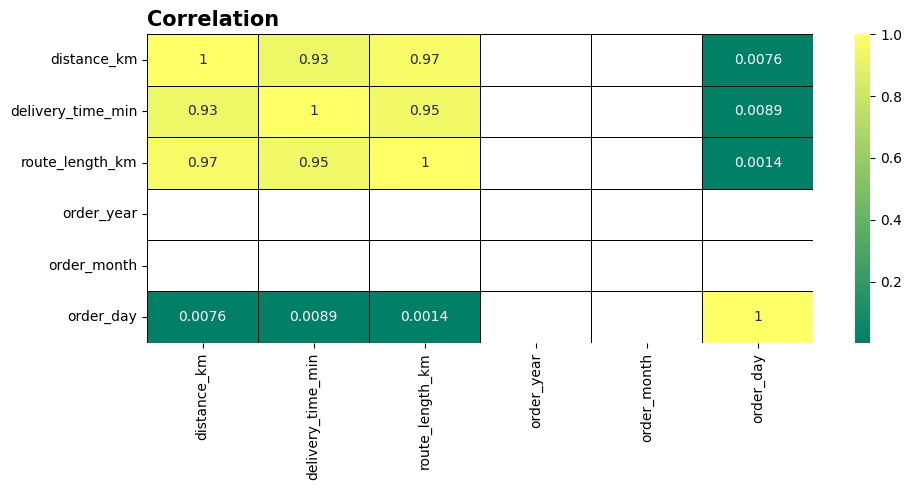

In [16]:
#================================================= Filtering Dataset =================================================#
# Correlation 
correlation = df.select_dtypes(include = ['number']).corr()
plt.figure(figsize = (10,5))
plt.title('Correlation',fontsize = 15,fontweight = 'bold',loc = 'left')
sns.heatmap(correlation,annot = True,cmap = 'summer',linecolor = 'black',linewidths = 0.5)
plt.tight_layout()
plt.show()

In [17]:
#================================================= Remove The Non-relations Columns =================================================#
df = df.drop(columns = ['order_year','order_month'],errors = 'ignore')

In [18]:
#================================================= Create A EDA Report =================================================#
from ydata_profiling import ProfileReport
report = ProfileReport(df,explorative = True)
report.to_file('Food_delivary-Report')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 1214.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
df.select_dtypes(include = ['category']).columns

Index(['traffic_level', 'delivery_mode', 'weather', 'restaurant_zone',
       'customer_zone'],
      dtype='object')

In [20]:
#=========================================== Feature Eng ===========================================#
numeric_features = ['distance_km','route_length_km','order_day']
categorical_nominal_features = ['delivery_mode','weather','restaurant_zone','customer_zone']
categorical_ordinal_features = ['traffic_level']
X = df[numeric_features + categorical_nominal_features + categorical_ordinal_features]
y = df['delivery_time_min']

In [21]:
#=========================================== Define Modules ===========================================#
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,KFold,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [22]:
#=========================================== Split the Dataset Into 2 Parts ===========================================#
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [23]:
#=========================================== Feature Eng ===========================================#
preprocessing = ColumnTransformer(transformers=[
    ('Num_features', StandardScaler(), numeric_features),
    ('Cat_nomial_features', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_nominal_features),
    ('Cat_ordinal_features', OrdinalEncoder(
        handle_unknown='use_encoded_value', 
        unknown_value=-1
    ), categorical_ordinal_features)
], remainder='passthrough')

In [24]:
#========================================= Try Multiple Models =========================================#
models = {
    ('LinearRegression',LinearRegression(n_jobs = -1)),
    ('RandomForestRegressor',RandomForestRegressor(random_state = 42)),
    ("XGBRegressor",XGBRegressor(random_state = 42))
}

In [25]:
results = []

for name, model in models:
    pipeline = Pipeline(steps=[
        ('preprocessing_data', preprocessing),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"\n#===================== {name} =====================#")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"Training Score: {pipeline.score(X_train, y_train):.4f}")
    print('#' + "=" * (len(name) + 22) + "#")
results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print(results_df)



#===================== LinearRegression =====================#
MAE: 5.5960
RMSE: 6.8424
R2 Score: 0.9174
Training Score: 0.9049
#======================================#

#===================== RandomForestRegressor =====================#
MAE: 5.0776
RMSE: 7.1219
R2 Score: 0.9106
Training Score: 0.9830
#===========================================#

#===================== XGBRegressor =====================#
MAE: 6.4662
RMSE: 8.1157
R2 Score: 0.8838
Training Score: 1.0000
#==================================#
                   Model       MAE      RMSE        R2
0       LinearRegression  5.596044  6.842428  0.917436
1  RandomForestRegressor  5.077550  7.121947  0.910552
2           XGBRegressor  6.466162  8.115733  0.883848


In [26]:
pipeline_model = Pipeline(steps = [
    ('preprocessing_data',preprocessing),
    ('regressor',RandomForestRegressor(random_state = 42))
])

In [27]:
#========================================== Hyper Tunning ==========================================#
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', None]
}
gridcv = GridSearchCV(estimator = pipeline_model,param_grid = param_grid,cv = 5,scoring = 'r2',n_jobs = -1,verbose = 0)
gridcv.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing_data',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('Num_features',
                                                                         StandardScaler(),
                                                                         ['distance_km',
                                                                          'route_length_km',
                                                                          'order_day']),
                                                                        ('Cat_nomial_features',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['delivery_mode',
                                                                          'weather',
                                                                          'restaurant_zone',
                                                                          'customer_zone']),
                                                                        ('Cat_ordi...
                                                                         OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                        unknown_value=-1),
                                                                         ['traffic_level'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [None, 10, 20],
                         'regressor__max_features': ['sqrt', 'log2', None],
                         'regressor__min_samples_leaf': [1, 2, 4],
                         'regressor__min_samples_split': [2, 5, 10],
                         'regressor__n_estimators': [100, 200, 300]},
             scoring='r2')

In [28]:
print(f"Best Score: {gridcv.best_score_:.4f}")
print(f"Best Parameters: {gridcv.best_params_}")

Best Score: 0.8657
Best Parameters: {'regressor__max_depth': None, 'regressor__max_features': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 300}


In [29]:
best_model = gridcv.best_estimator_
y_pred = best_model.predict(X_test)

In [30]:
print('MAE: ',mean_absolute_error(y_test,y_pred))
print('MSE: ',mean_squared_error(y_test,y_pred))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2: ',r2_score(y_test,y_pred))
print("Training Score: ",best_model.score(X_train,y_train))


MAE:  5.197805385930252
MSE:  48.349588641878135
RMSE:  6.953386846845078
R2:  0.9147360703173676
Training Score:  0.9528202345106651


In [31]:
pipeline_model_xgb = Pipeline(steps = [
    ('preprocessing_data',preprocessing),
    ('regressor',XGBRegressor(random_state = 42))
])

In [32]:
#========================================== Hyper Tunning ==========================================#
param_grid_xgb = {
    'regressor__n_estimators': [100, 200, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 5, 7],             
    'regressor__subsample': [0.7, 0.8, 1.0],       
    'regressor__colsample_bytree': [0.7, 0.8, 1.0] 
}

gridcv = GridSearchCV(estimator = pipeline_model_xgb,param_grid = param_grid_xgb,cv = 5,scoring = 'r2',n_jobs = -1,verbose = 0)
gridcv.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing_data',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('Num_features',
                                                                         StandardScaler(),
                                                                         ['distance_km',
                                                                          'route_length_km',
                                                                          'order_day']),
                                                                        ('Cat_nomial_features',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['delivery_mode',
                                                                          'weather',
                                                                          'restaurant_zone',
                                                                          'customer_zone']),
                                                                        ('Cat_ordi...
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'regressor__colsample_bytree': [0.7, 0.8, 1.0],
                         'regressor__learning_rate': [0.01, 0.05, 0.1],
                         'regressor__max_depth': [3, 5, 7],
                         'regressor__n_estimators': [100, 200, 500],
                         'regressor__subsample': [0.7, 0.8, 1.0]},
             scoring='r2')

In [33]:
best_model_xgb = gridcv.best_estimator_
y_pred = best_model_xgb.predict(X_test)

In [34]:
print('MAE: ',mean_absolute_error(y_test,y_pred))
print('MSE: ',mean_squared_error(y_test,y_pred))
print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2: ',r2_score(y_test,y_pred))
print("Training Score: ",best_model_xgb.score(X_train,y_train))


MAE:  5.168335366249084
MSE:  43.25076735593917
RMSE:  6.576531559715894
R2:  0.9237277815562933
Training Score:  0.9631250972325905


In [35]:
#======================================== model's performance =========================================#
model_dict = {
    'Model' : ['LinearRegression','RandomForestRegressor','XGBRegressor','TunnedRedomForestRegressor','TunnedXGBRegeressor'],
    'MAE' : [5.5960,5.0776,6.4662,5.1978,5.1683],
    'RMSE' : [6.8424,7.1219,8.1157,6.9533,6.5765],
    'Training score' : [0.9049,0.9830,1.0000,0.9528,0.9631],
    'R2': [0.9174,0.9106,0.8838,0.9147,0.9237]
}
model_data = pd.DataFrame(model_dict)
model_data

,Model,MAE,RMSE,Training score,R2
0,LinearRegression,5.5960,6.8424,0.9049,0.9174
1,RandomForestRegressor,5.0776,7.1219,0.9830,0.9106
2,XGBRegressor,6.4662,8.1157,1.0000,0.8838
3,TunnedRedomForestRegressor,5.1978,6.9533,0.9528,0.9147
4,TunnedXGBRegeressor,5.1683,6.5765,0.9631,0.9237


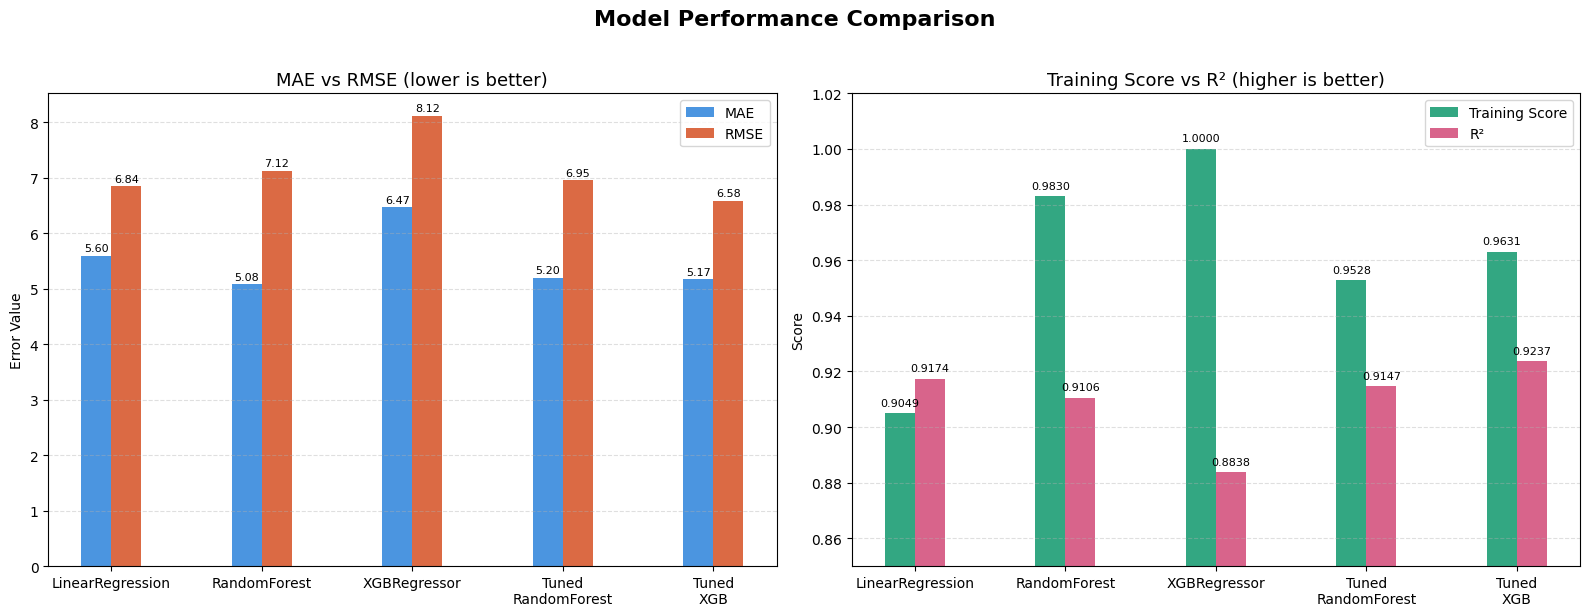

In [36]:
#===================================== Model Performance Comparison =====================================#
models = [
    'LinearRegression',
    'RandomForest',
    'XGBRegressor',
    'Tuned\nRandomForest',
    'Tuned\nXGB'
]
 
mae   = [5.5960, 5.0776, 6.4662, 5.1978, 5.1683]
rmse  = [6.8424, 7.1219, 8.1157, 6.9533, 6.5765]
train = [0.9049, 0.9830, 1.0000, 0.9528, 0.9631]
r2    = [0.9174, 0.9106, 0.8838, 0.9147, 0.9237]
 
x = np.arange(len(models))
width = 0.2
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, mae,  width, label='MAE',  color='#378ADD', alpha=0.9)
bars2 = ax1.bar(x + width/2, rmse, width, label='RMSE', color='#D85A30', alpha=0.9)
 
ax1.set_title('MAE vs RMSE (lower is better)', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=10)
ax1.set_ylabel('Error Value')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)
 
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax2 = axes[1]
bars3 = ax2.bar(x - width/2, train, width, label='Training Score', color='#1D9E75', alpha=0.9)
bars4 = ax2.bar(x + width/2, r2,    width, label='R²',             color='#D4537E', alpha=0.9)
 
ax2.set_title('Training Score vs R² (higher is better)', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=10)
ax2.set_ylabel('Score')
ax2.set_ylim(0.85, 1.02)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)
 
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
 
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
#=============================================== Final Model IS XGBRegressor_tunned ===============================================#
# Save The Model
import joblib
joblib.dump(best_model_xgb,'best_model_xgb_pipeline.pkl')
print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [49]:
df.shape[1]

9